Tools docs: https://docs.google.com/document/d/189dWz0sP6ySA4htE7svEpLP5-RykpQyfCk2AZpmHwg8/edit?usp=sharing

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Any
import requests
import math
import os

In [28]:
load_dotenv()

True

In [29]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [30]:
# Tools
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)



@tool
def calculator(expression: str) -> str:
    """
    Useful for simple math calculations.
    Input should be a valid math expression.
    Example: 2 + 2, math.sqrt(16), 10 * 5
    """

    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "min": min,
            "max": max,
            "sum": sum
        }

        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)

    except Exception as e:
        return f"Calculation error: {str(e)}"


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=HTM6MLWOXVJCK77J"
    r = requests.get(url)
    return r.json()



@tool
def get_current_weather(location: str) -> str:
    """
    Get the current real-time weather for a given city or location.

    Args:
        location: City or location name, for example:
                  "Dhaka", "London, UK", or "New York, US".

    Returns:
        A formatted current weather report.
    """

    api_key = os.getenv("OPENWEATHER_API_KEY")

    if not api_key:
        return (
            "Weather API key is missing. "
            "Set the OPENWEATHER_API_KEY environment variable."
        )

    try:
        # Step 1: Convert the location name into latitude and longitude
        geocoding_url = "https://api.openweathermap.org/geo/1.0/direct"

        geocoding_params = {
            "q": location,
            "limit": 1,
            "appid": api_key,
        }

        geo_response = requests.get(
            geocoding_url,
            params=geocoding_params,
            timeout=10,
        )
        geo_response.raise_for_status()

        locations: list[dict[str, Any]] = geo_response.json()

        if not locations:
            return f"Could not find the location: {location}"

        latitude = locations[0]["lat"]
        longitude = locations[0]["lon"]
        resolved_name = locations[0].get("name", location)
        country = locations[0].get("country", "")
        state = locations[0].get("state", "")

        # Step 2: Get current weather using latitude and longitude
        weather_url = "https://api.openweathermap.org/data/2.5/weather"

        weather_params = {
            "lat": latitude,
            "lon": longitude,
            "appid": api_key,
            "units": "metric",
        }

        weather_response = requests.get(
            weather_url,
            params=weather_params,
            timeout=10,
        )
        weather_response.raise_for_status()

        weather_data = weather_response.json()

        temperature = weather_data["main"]["temp"]
        feels_like = weather_data["main"]["feels_like"]
        humidity = weather_data["main"]["humidity"]
        pressure = weather_data["main"]["pressure"]
        description = weather_data["weather"][0]["description"]
        wind_speed = weather_data.get("wind", {}).get("speed", "N/A")
        visibility_meters = weather_data.get("visibility")

        visibility_km = (
            round(visibility_meters / 1000, 1)
            if visibility_meters is not None
            else "N/A"
        )

        location_parts = [resolved_name]

        if state:
            location_parts.append(state)

        if country:
            location_parts.append(country)

        display_location = ", ".join(location_parts)

        return (
            f"Current weather in {display_location}:\n"
            f"- Condition: {description.title()}\n"
            f"- Temperature: {temperature}°C\n"
            f"- Feels like: {feels_like}°C\n"
            f"- Humidity: {humidity}%\n"
            f"- Pressure: {pressure} hPa\n"
            f"- Wind speed: {wind_speed} m/s\n"
            f"- Visibility: {visibility_km} km"
        )

    except requests.Timeout:
        return "The weather service request timed out. Please try again."

    except requests.HTTPError as error:
        status_code = error.response.status_code if error.response else "unknown"

        if status_code == 401:
            return "The OpenWeather API key is invalid or inactive."

        return f"Weather API returned an HTTP error: {status_code}"

    except requests.RequestException as error:
        return f"Could not connect to the weather service: {error}"

    except (KeyError, TypeError, ValueError) as error:
        return f"Unexpected weather API response: {error}"

In [31]:
# Make tool list
tools = [search_tool,calculator, get_stock_price,get_current_weather]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [32]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [33]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

In [34]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [35]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")    

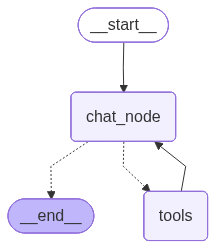

In [36]:
chatbot = graph.compile()

chatbot

In [37]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)


Hello! I'm a large language model, able to assist with a wide range of tasks. What can I do for you today?


In [38]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 8989898*90909090+5404040?")]})
print(out["messages"][-1].content)

The result of 8989898*90909090+5404040 is 817263451776860.


In [ ]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="what is the new movie releases in 2026")]})
print(out["messages"][-1].content[0])

[{'type': 'text', 'text': "Here are some new movie releases scheduled for 2026:\n\n**March 2026:**\n*   *Project Hail Mary*\n\n**April 2026:**\n*   *The Super Mario Galaxy Movie* (April 3)\n*   *Fireflies at El Mozote* (April 17)\n*   *Michael* (April 24)\n\n**May 2026:**\n*   *The Devil Wears Prada 2* (May 1)\n*   Boots Riley's sophomore film (May 22)\n*   A Sacha Baron Cohen satire (May 22)\n*   A horror film about a couple pursued by a demonic stalker (May 22)\n*   *The Sheep Detectives* (May 8)\n*   *Mortal Kombat II* (May 8)\n*   *Obsession* (May 15)\n*   *Star Wars: The Mandalorian and Grogu* (May 22)\n*   *Tuner* (May 22)\n*   *Passenger* (May 22)\n*   *I Love Boosters* (May 22)\n*   *The Breadwinner* (May 29)\n*   *Power Ballad* (May 29)\n*   *Pressure* (May 29)\n*   *Backrooms* (May 29)\n*   *Drishyam 3* (May 21)\n*   *Hokum* (May 1)\n*   *Billie Eilish - Hit Me Hard and Soft: The Tour* (May 8)\n*   *NT Live: Les Liaisons Dangereuses* (May 27)\n\n**June 2026:**\n*   *Scary Mov

In [42]:
print(out["messages"][-1].content[0]['text'])

Here are some new movie releases scheduled for 2026:

**March 2026:**
*   *Project Hail Mary*

**April 2026:**
*   *The Super Mario Galaxy Movie* (April 3)
*   *Fireflies at El Mozote* (April 17)
*   *Michael* (April 24)

**May 2026:**
*   *The Devil Wears Prada 2* (May 1)
*   Boots Riley's sophomore film (May 22)
*   A Sacha Baron Cohen satire (May 22)
*   A horror film about a couple pursued by a demonic stalker (May 22)
*   *The Sheep Detectives* (May 8)
*   *Mortal Kombat II* (May 8)
*   *Obsession* (May 15)
*   *Star Wars: The Mandalorian and Grogu* (May 22)
*   *Tuner* (May 22)
*   *Passenger* (May 22)
*   *I Love Boosters* (May 22)
*   *The Breadwinner* (May 29)
*   *Power Ballad* (May 29)
*   *Pressure* (May 29)
*   *Backrooms* (May 29)
*   *Drishyam 3* (May 21)
*   *Hokum* (May 1)
*   *Billie Eilish - Hit Me Hard and Soft: The Tour* (May 8)
*   *NT Live: Les Liaisons Dangereuses* (May 27)

**June 2026:**
*   *Scary Movie* (June 5)
*   *Masters of the Universe* (June 5)
*   *Th

In [43]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

[{'type': 'text', 'text': 'The stock price of Apple (AAPL) is 295.63. To purchase 50 shares, it would cost 14781.5.', 'extras': {'signature': 'CqwBAQw51sepZs7IrPTGSUYcba+NeQiY+/hk5E3bQoSYW6TO/aVH396w2LgCS2p1iHwIo8qM3biTzSlbKQ3MMfLXMUyuvW6XPDvMMxzGnIS9aTkftKQu9LOpTuHi2w/fnKkudj8iMpH5qc6IWUo4DkWeDaZHcv2GgMVEPUpIgwzCk2OvPLWlMW0vgKOXj6jsBC6VwBs/MuYfYK+ckBKUnlbHvYWRyf4HanITVqdn/w=='}}]


In [44]:
print(out["messages"][-1].content[0]['text'])

The stock price of Apple (AAPL) is 295.63. To purchase 50 shares, it would cost 14781.5.


In [45]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the current weather in New York?")]})
print(out["messages"][-1].content)

The current weather in New York, New York, US is moderate rain, with a temperature of 25.47°C, feeling like 26.19°C. The humidity is 81%, pressure is 1007 hPa, wind speed is 1.79 m/s, and visibility is 10.0 km.
